# Case Study — What scikit-learn Hides: A 3–7–7–1 Neural Network

This case study is designed for a later chapter, after the mathematics of neural-network learning has already been developed from first principles.

For the first several chapters, we deliberately **did not hide the machinery**. We developed:

- weighted sums and bias terms,
- sigmoid activation,
- likelihood and cross-entropy loss,
- gradients and gradient descent,
- the chain rule,
- forward propagation,
- reverse-mode automatic differentiation,
- backpropagation,
- mini-batch training,
- hold-out testing and classification metrics.

Now we will build a neural network using a modern machine-learning library and ask a different question:

> **What work is scikit-learn performing for us when a few lines of Python replace pages of mathematics?**

The network architecture is

\[
\boxed{3 \rightarrow 7 \rightarrow 7 \rightarrow 1}
\]

for binary classification of two synthetic 3-dimensional Gaussian populations.


<div style="background:#eef5ff; border-left:5px solid #4c78a8; padding:12px 16px; margin:12px 0;">
<b>Central teaching idea</b><br>
A high-level library does not remove the mathematics. It packages the mathematics behind an API.  
Our goal is to identify exactly what has been packaged.
</div>


## 1. Imports and reproducibility

This cell loads four categories of tools:

1. **NumPy** — numerical arrays and synthetic Gaussian data.
2. **Matplotlib** — visualization.
3. **scikit-learn preprocessing and model-selection tools** — train/hold-out splitting and feature standardization.
4. **scikit-learn neural-network and metric tools** — training the network and evaluating it.

The random seed makes the experiment reproducible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    RocCurveDisplay
)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


## 2. Manufacture two 3-D Gaussian classes

We deliberately create the data ourselves so that we know the underlying statistical structure.

Each observation has three features:

\[
\mathbf{x}_i =
\begin{bmatrix}
x_{i1}\\
x_{i2}\\
x_{i3}
\end{bmatrix}.
\]

Class 0 and Class 1 have different means **and** different covariance matrices.

The neural network will not be told that the samples are Gaussian. It receives only the feature matrix \(X\) and class labels \(y\).


In [2]:
# -------------------------------------------------------------------------
# Class 0
# -------------------------------------------------------------------------
mu0 = np.array([3.0, 2.0, 1.0])

cov0 = np.array([
    [2.5,  0.4,  0.0],
    [0.4,  1.5,  0.3],
    [0.0,  0.3,  1.0]
])

# -------------------------------------------------------------------------
# Class 1
# -------------------------------------------------------------------------
mu1 = np.array([-2.0, -1.0, 2.5])

cov1 = np.array([
    [1.5, -0.6,  0.2],
    [-0.6, 2.5,  0.8],
    [0.2,  0.8,  2.0]
])

# Draw 1,000 samples from each class.
N = 1000

X0 = rng.multivariate_normal(mu0, cov0, size=N)
X1 = rng.multivariate_normal(mu1, cov1, size=N)

# Numerical class labels.
y0 = np.zeros(N, dtype=int)
y1 = np.ones(N, dtype=int)

# Combine both classes into one supervised-learning dataset.
X = np.vstack((X0, X1))
y = np.concatenate((y0, y1))

print("Feature matrix X:", X.shape)
print("Label vector y  :", y.shape)
print("Class 0 samples :", np.sum(y == 0))
print("Class 1 samples :", np.sum(y == 1))


Feature matrix X: (2000, 3)
Label vector y  : (2000,)
Class 0 samples : 1000
Class 1 samples : 1000


### What was created?

The final feature matrix has shape

\[
X \in \mathbb{R}^{2000\times3}.
\]

That means:

- 2,000 observations,
- 3 numerical features per observation.

The label vector has 2,000 entries:

\[
y_i\in\{0,1\}.
\]

This is why the network will require exactly **three input nodes**.


## 3. Visualize the two populations in the original three-dimensional feature space


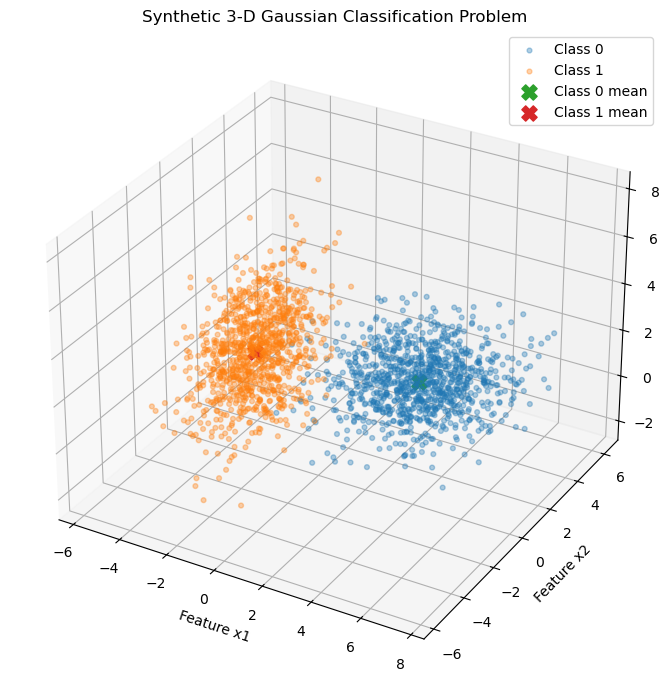

In [3]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X0[:, 0], X0[:, 1], X0[:, 2],
    s=12, alpha=0.35, label="Class 0"
)

ax.scatter(
    X1[:, 0], X1[:, 1], X1[:, 2],
    s=12, alpha=0.35, label="Class 1"
)

ax.scatter(
    mu0[0], mu0[1], mu0[2],
    s=120, marker="X", label="Class 0 mean"
)

ax.scatter(
    mu1[0], mu1[1], mu1[2],
    s=120, marker="X", label="Class 1 mean"
)

ax.set_xlabel("Feature x1")
ax.set_ylabel("Feature x2")
ax.set_zlabel("Feature x3")
ax.set_title("Synthetic 3-D Gaussian Classification Problem")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Create training and hold-out sets

The model must be evaluated using samples that did not participate in parameter learning.

We reserve 20% of the data for hold-out testing:

\[
2000(0.8)=1600
\]

training observations and

\[
2000(0.2)=400
\]

hold-out observations.

`stratify=y` preserves the class balance in both partitions.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Training observations:", X_train.shape[0])
print("Hold-out observations:", X_test.shape[0])

print("\nTraining class counts:")
print("Class 0:", np.sum(y_train == 0))
print("Class 1:", np.sum(y_train == 1))

print("\nHold-out class counts:")
print("Class 0:", np.sum(y_test == 0))
print("Class 1:", np.sum(y_test == 1))


Training observations: 1600
Hold-out observations: 400

Training class counts:
Class 0: 800
Class 1: 800

Hold-out class counts:
Class 0: 200
Class 1: 200


## 5. Preprocessing with `StandardScaler`

Neural-network optimization is usually easier when feature magnitudes are comparable.

`StandardScaler` learns, for each feature \(j\),

\[
\mu_j = \text{training-set mean},
\qquad
s_j = \text{training-set standard deviation},
\]

and transforms an observation using

\[
z_{ij} = \frac{x_{ij}-\mu_j}{s_j}.
\]

There is an important asymmetry:

- `fit_transform(X_train)` **learns** the scaling parameters from the training data and applies them.
- `transform(X_test)` **reuses** those same training-derived parameters.

We do **not** fit the scaler on the hold-out set. Doing so would allow information from the hold-out population to leak into the training process.


In [5]:
scaler = StandardScaler()

# Learn training-set means/stds AND transform the training data.
X_train_scaled = scaler.fit_transform(X_train)

# Reuse the already-learned transformation on hold-out data.
X_test_scaled = scaler.transform(X_test)

print("Means learned by StandardScaler:")
print(scaler.mean_)

print("\nStandard deviations learned by StandardScaler:")
print(scaler.scale_)

print("\nScaled training feature means:")
print(X_train_scaled.mean(axis=0))

print("\nScaled training feature standard deviations:")
print(X_train_scaled.std(axis=0))


Means learned by StandardScaler:
[0.46913033 0.56267326 1.75849801]

Standard deviations learned by StandardScaler:
[2.86545366 2.02891693 1.41248298]

Scaled training feature means:
[-1.92103278e-16 -6.49480469e-16  3.11500825e-15]

Scaled training feature standard deviations:
[1. 1. 1.]


### `StandardScaler` versus `MinMaxScaler`

We use `StandardScaler` here because the input populations are Gaussian-like and standard-deviation scaling has a natural interpretation.

Another common choice is `MinMaxScaler`, which maps a feature to a specified interval, typically \([0,1]\):

\[
x'=
\frac{x-x_{\min}}
{x_{\max}-x_{\min}}.
\]

Both are preprocessing transformations. Neither one is part of the neural network itself.

<div style="background:#fff7e6; border-left:5px solid #d99a2b; padding:12px 16px; margin:12px 0;">
<b>What scikit-learn has already hidden:</b><br>
Even before the neural network appears, <code>StandardScaler</code> has packaged the calculation, storage, and reuse of three training-set means and three training-set standard deviations.
</div>


## 6. The network before the code

Before asking scikit-learn to create the model, we should know exactly what mathematical object we want.

For one observation \(\mathbf{x}\), the first hidden layer computes

\[
\mathbf{z}^{(1)}
=
\mathbf{x}^{T}W^{(1)}+\mathbf{b}^{(1)},
\]

followed by sigmoid activation

\[
\mathbf{a}^{(1)}
=
\sigma\left(\mathbf{z}^{(1)}\right).
\]

The second hidden layer computes

\[
\mathbf{z}^{(2)}
=
\mathbf{a}^{(1)}W^{(2)}+\mathbf{b}^{(2)},
\]

\[
\mathbf{a}^{(2)}
=
\sigma\left(\mathbf{z}^{(2)}\right).
\]

The binary output layer then combines the seven second-layer activations into the final class probability.

The required parameter shapes are

\[
W^{(1)}\in\mathbb{R}^{3\times7},
\qquad
W^{(2)}\in\mathbb{R}^{7\times7},
\qquad
W^{(3)}\in\mathbb{R}^{7\times1},
\]

with biases

\[
\mathbf b^{(1)}\in\mathbb{R}^{7},
\qquad
\mathbf b^{(2)}\in\mathbb{R}^{7},
\qquad
b^{(3)}\in\mathbb{R}.
\]

Therefore the model contains

\[
3(7)+7(7)+7(1)=77
\]

weights and

\[
7+7+1=15
\]

biases:

\[
\boxed{92\text{ trainable parameters}}.
\]


## 7. Draw the complete 3–7–7–1 architecture


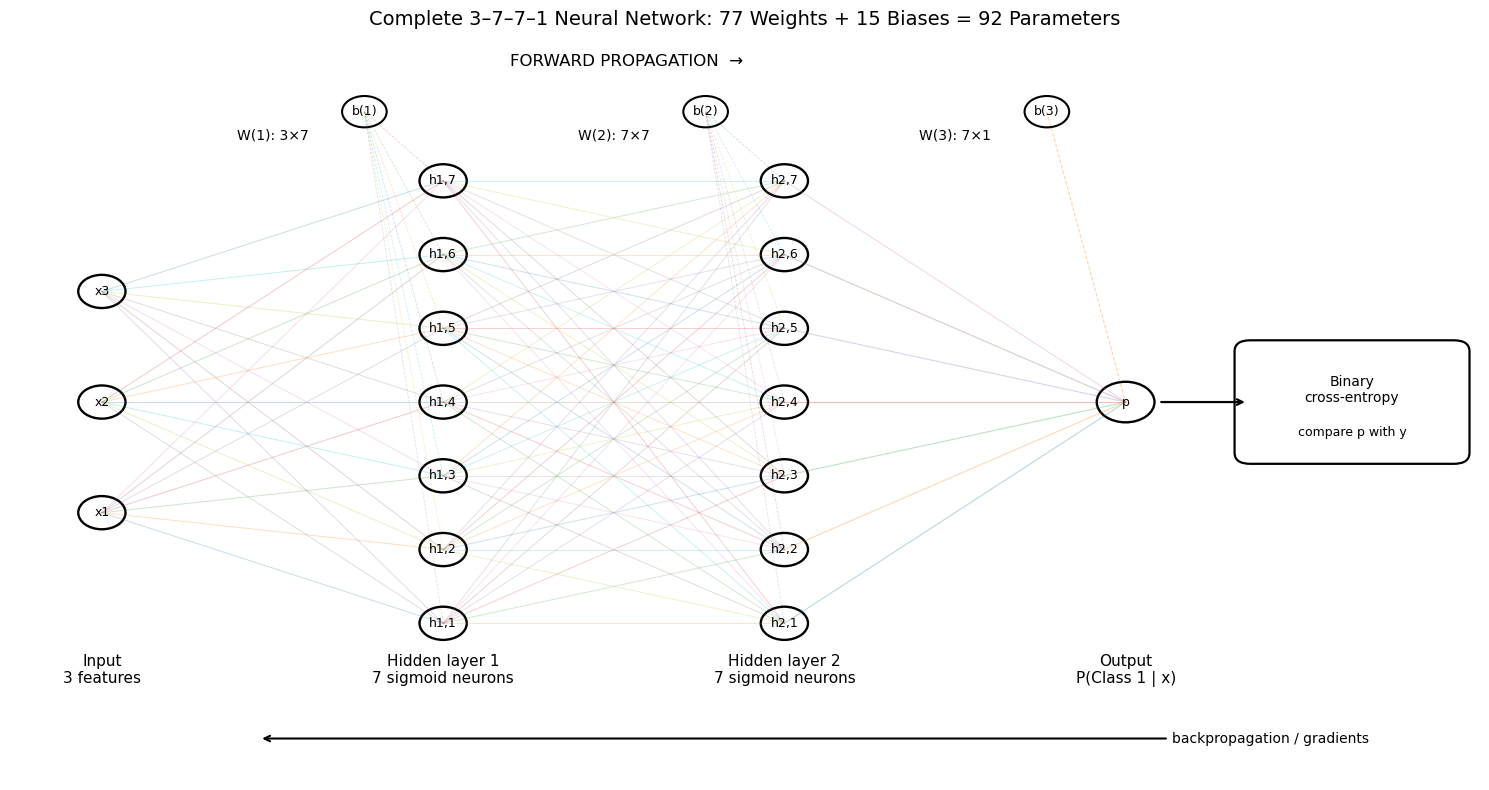

In [6]:
from matplotlib.patches import Circle, FancyBboxPatch

# Layer node coordinates.
x_positions = [0.0, 2.6, 5.2, 7.8]

input_y = np.linspace(-1.2, 1.2, 3)
h1_y = np.linspace(-2.4, 2.4, 7)
h2_y = np.linspace(-2.4, 2.4, 7)
output_y = np.array([0.0])

fig, ax = plt.subplots(figsize=(15, 8))

# -------------------------
# Draw all 77 weighted edges
# -------------------------
for y0_ in input_y:
    for y1_ in h1_y:
        ax.plot([x_positions[0], x_positions[1]], [y0_, y1_],
                linewidth=0.7, alpha=0.25)

for y1_ in h1_y:
    for y2_ in h2_y:
        ax.plot([x_positions[1], x_positions[2]], [y1_, y2_],
                linewidth=0.7, alpha=0.22)

for y2_ in h2_y:
    ax.plot([x_positions[2], x_positions[3]], [y2_, output_y[0]],
            linewidth=0.8, alpha=0.3)

# -------------------------
# Draw neurons
# -------------------------
def draw_layer(x, ys, labels, radius=0.18):
    for y_, label in zip(ys, labels):
        ax.add_patch(Circle((x, y_), radius, fill=False, linewidth=1.7))
        ax.text(x, y_, label, ha="center", va="center", fontsize=9)

draw_layer(x_positions[0], input_y, ["x1", "x2", "x3"])
draw_layer(x_positions[1], h1_y, [f"h1,{i+1}" for i in range(7)])
draw_layer(x_positions[2], h2_y, [f"h2,{i+1}" for i in range(7)])
draw_layer(x_positions[3], output_y, ["p"], radius=0.22)

# Bias nodes.
bias_x = [2.0, 4.6, 7.2]
bias_y = 3.15

for bx, label in zip(bias_x, ["b(1)", "b(2)", "b(3)"]):
    ax.add_patch(Circle((bx, bias_y), 0.17, fill=False, linewidth=1.5))
    ax.text(bx, bias_y, label, ha="center", va="center", fontsize=9)

# Bias arrows.
for y_ in h1_y:
    ax.plot([bias_x[0], x_positions[1]], [bias_y, y_], linestyle="--",
            linewidth=0.55, alpha=0.25)

for y_ in h2_y:
    ax.plot([bias_x[1], x_positions[2]], [bias_y, y_], linestyle="--",
            linewidth=0.55, alpha=0.25)

ax.plot([bias_x[2], x_positions[3]], [bias_y, output_y[0]],
        linestyle="--", linewidth=0.75, alpha=0.35)

# Layer and matrix labels.
ax.text(x_positions[0], -3.05, "Input\n3 features", ha="center", fontsize=11)
ax.text(x_positions[1], -3.05, "Hidden layer 1\n7 sigmoid neurons", ha="center", fontsize=11)
ax.text(x_positions[2], -3.05, "Hidden layer 2\n7 sigmoid neurons", ha="center", fontsize=11)
ax.text(x_positions[3], -3.05, "Output\nP(Class 1 | x)", ha="center", fontsize=11)

ax.text(1.3, 2.85, "W(1): 3×7", ha="center", fontsize=10)
ax.text(3.9, 2.85, "W(2): 7×7", ha="center", fontsize=10)
ax.text(6.5, 2.85, "W(3): 7×1", ha="center", fontsize=10)

# Loss block.
loss_box = FancyBboxPatch(
    (8.75, -0.55), 1.55, 1.1,
    boxstyle="round,pad=0.12",
    fill=False,
    linewidth=1.6
)
ax.add_patch(loss_box)
ax.text(9.525, 0.13, "Binary\ncross-entropy", ha="center", va="center", fontsize=10)
ax.text(9.525, -0.33, "compare p with y", ha="center", va="center", fontsize=9)

ax.annotate(
    "",
    xy=(8.73, 0.0),
    xytext=(8.05, 0.0),
    arrowprops=dict(arrowstyle="->", linewidth=1.6)
)

# Backpropagation arrow.
ax.annotate(
    "backpropagation / gradients",
    xy=(1.2, -3.65),
    xytext=(8.9, -3.65),
    arrowprops=dict(arrowstyle="->", linewidth=1.5),
    ha="center",
    va="center",
    fontsize=10
)

ax.text(4.0, 3.65, "FORWARD PROPAGATION  →", ha="center", fontsize=12)
ax.set_xlim(-0.7, 10.5)
ax.set_ylim(-4.1, 4.0)
ax.axis("off")
ax.set_title("Complete 3–7–7–1 Neural Network: 77 Weights + 15 Biases = 92 Parameters",
             fontsize=14)
plt.tight_layout()
plt.show()


## 8. Ask scikit-learn to build the model

Now compare the mathematical description above with the code required by the library.


In [7]:
model = MLPClassifier(
    hidden_layer_sizes=(7, 7),  # hidden layers only; 3 inputs and 1 output are inferred
    activation="logistic",      # sigmoid activation in both hidden layers
    solver="adam",              # Adam optimizer
    learning_rate_init=0.01,
    batch_size=32,
    max_iter=200,
    early_stopping=False,
    random_state=RANDOM_SEED
)

print(model)


MLPClassifier(activation='logistic', batch_size=32, hidden_layer_sizes=(7, 7),
              learning_rate_init=0.01, random_state=42)


<div style="background:#eef5ff; border-left:5px solid #4c78a8; padding:12px 16px; margin:12px 0;">
<b>What those few lines have specified for us</b><br><br>
<code>hidden_layer_sizes=(7,7)</code> tells scikit-learn to create the two hidden layers.<br>
The three input features are inferred from <code>X_train_scaled.shape[1]</code>.<br>
The binary output is inferred from the two unique values in <code>y_train</code>.<br>
<code>activation="logistic"</code> selects sigmoid hidden-layer activation.<br>
<code>batch_size=32</code> defines the mini-batch size.<br>
<code>solver="adam"</code> chooses the optimization algorithm.<br><br>
The library will allocate, initialize, differentiate, and update the 92 trainable parameters.
</div>


## 9. What does `batch_size=32` mean?

The training set contains 1,600 observations.

With batches of 32,

\[
\frac{1600}{32}=50
\]

mini-batches are required for one complete pass through the training data.

For each mini-batch, the learning system approximately performs:

\[
\text{forward pass}
\rightarrow
\text{loss}
\rightarrow
\text{backpropagation}
\rightarrow
\text{Adam parameter update}.
\]

After about 50 such updates, the network has seen one epoch of training data.

`max_iter=200` permits up to 200 training epochs.


## 10. The most deceptive line in the notebook: `fit()`

The Python looks almost trivial:

```python
model.fit(X_train_scaled, y_train)
```

Mathematically, it is not trivial at all.

This one API call hides the repeated execution of almost everything developed earlier in the book:

1. parameter initialization,
2. mini-batch construction,
3. forward propagation,
4. sigmoid evaluation,
5. output probability calculation,
6. cross-entropy loss,
7. reverse differentiation/backpropagation,
8. gradient calculation for every weight and bias,
9. Adam parameter updates,
10. repeated epochs of training.

The mathematics did not disappear.

**The API hid its implementation.**


In [8]:
model.fit(X_train_scaled, y_train)

print("Training stopped after", model.n_iter_, "epochs")
print("Final training loss:", model.loss_)


Training stopped after 62 epochs
Final training loss: 0.027591169131412838


## 11. The loss being minimized

For binary classification, the model is trained using a log-loss/cross-entropy objective.

For true labels \(y_i\in\{0,1\}\) and predicted positive-class probabilities \(\hat p_i\),

\[
L
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(\hat p_i)
+
(1-y_i)\log(1-\hat p_i)
\right].
\]

The network is therefore **not directly optimizing classification accuracy**.

It is minimizing a differentiable probabilistic loss. Accuracy is evaluated afterward.


## 12. Plot the training-loss history


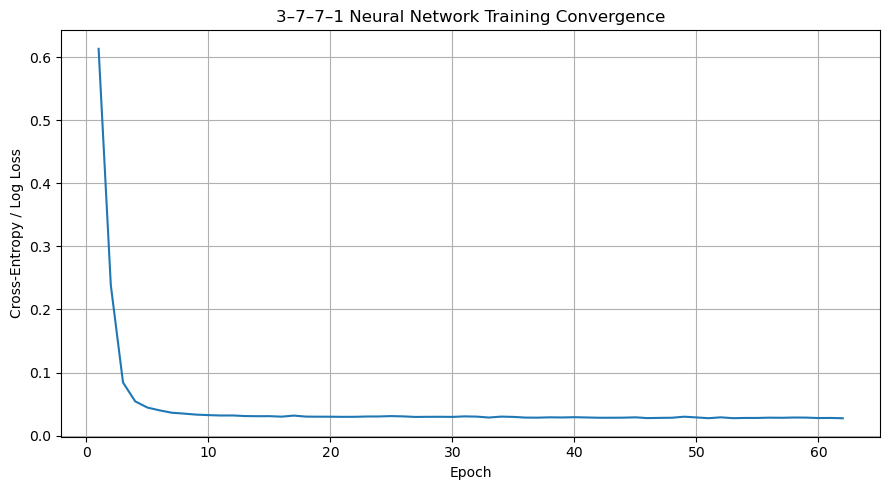

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(
    np.arange(1, len(model.loss_curve_) + 1),
    model.loss_curve_
)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy / Log Loss")
plt.title("3–7–7–1 Neural Network Training Convergence")
plt.grid(True)
plt.tight_layout()
plt.show()


## 13. Generate hold-out predictions

`predict()` converts the network output into class decisions.

`predict_proba()` retains the class probabilities and is therefore more informative.


In [11]:
y_pred = model.predict(X_test_scaled)
probabilities = model.predict_proba(X_test_scaled)

# For binary classification:
# probabilities[:,0] = P(Class 0 | x)
# probabilities[:,1] = P(Class 1 | x)
p_class1 = probabilities[:, 1]

for i in range(10):
    print(
        f"Sample {i:2d}: "
        f"P(Class 0)={probabilities[i,0]:.4f}, "
        f"P(Class 1)={probabilities[i,1]:.4f}, "
        f"Predicted={y_pred[i]}, "
        f"True={y_test[i]}"
    )


Sample  0: P(Class 0)=0.9991, P(Class 1)=0.0009, Predicted=0, True=0
Sample  1: P(Class 0)=0.9993, P(Class 1)=0.0007, Predicted=0, True=0
Sample  2: P(Class 0)=0.6087, P(Class 1)=0.3913, Predicted=0, True=1
Sample  3: P(Class 0)=0.9980, P(Class 1)=0.0020, Predicted=0, True=0
Sample  4: P(Class 0)=0.9993, P(Class 1)=0.0007, Predicted=0, True=0
Sample  5: P(Class 0)=0.0008, P(Class 1)=0.9992, Predicted=1, True=1
Sample  6: P(Class 0)=0.0019, P(Class 1)=0.9981, Predicted=1, True=1
Sample  7: P(Class 0)=0.9993, P(Class 1)=0.0007, Predicted=0, True=0
Sample  8: P(Class 0)=0.9989, P(Class 1)=0.0011, Predicted=0, True=0
Sample  9: P(Class 0)=0.2021, P(Class 1)=0.7979, Predicted=1, True=1


## 14. Confusion matrix

The confusion matrix preserves information that a single accuracy number hides.

\[
\begin{array}{c|cc}
&\text{Predicted 0}&\text{Predicted 1}\\
\hline
\text{Actual 0}&TN&FP\\
\text{Actual 1}&FN&TP
\end{array}
\]


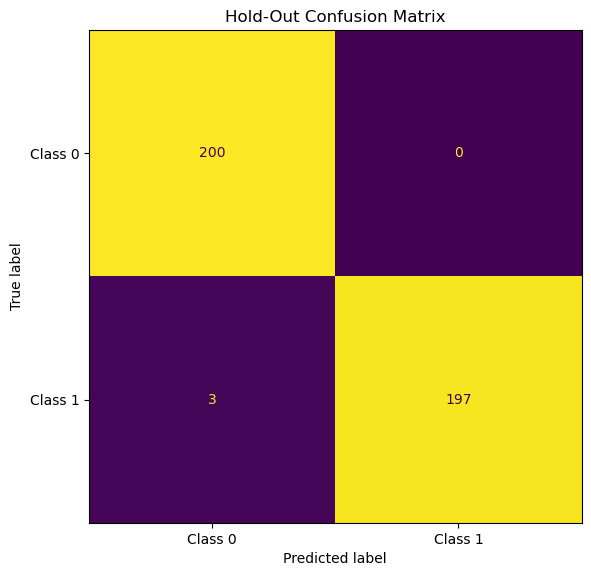

TN = 200
FP = 0
FN = 3
TP = 197


In [12]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("Hold-Out Confusion Matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()

print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)


## 15. Metrics derived from the confusion matrix

For Class 1 treated as the positive class:

\[
\text{Accuracy}
=
\frac{TP+TN}{TP+TN+FP+FN},
\]

\[
\text{Precision}
=
\frac{TP}{TP+FP},
\]

\[
\text{Recall/Sensitivity}
=
\frac{TP}{TP+FN},
\]

\[
\text{Specificity}
=
\frac{TN}{TN+FP},
\]

\[
F_1
=
2\frac{\text{Precision}\cdot\text{Recall}}
{\text{Precision}+\text{Recall}}.
\]

We also calculate false-positive rate, false-negative rate, balanced accuracy, and ROC-AUC.


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, p_class1)

specificity = tn / (tn + fp)
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print("Hold-Out Classification Metrics")
print("--------------------------------")
print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall / Sensitivity: {recall:.4f}")
print(f"Specificity         : {specificity:.4f}")
print(f"F1 Score            : {f1:.4f}")
print(f"Balanced Accuracy   : {balanced_accuracy:.4f}")
print(f"False Positive Rate : {false_positive_rate:.4f}")
print(f"False Negative Rate : {false_negative_rate:.4f}")
print(f"ROC-AUC             : {roc_auc:.4f}")


Hold-Out Classification Metrics
--------------------------------
Accuracy            : 0.9925
Precision           : 1.0000
Recall / Sensitivity: 0.9850
Specificity         : 1.0000
F1 Score            : 0.9924
Balanced Accuracy   : 0.9925
False Positive Rate : 0.0000
False Negative Rate : 0.0150
ROC-AUC             : 0.9999


## 16. ROC curve


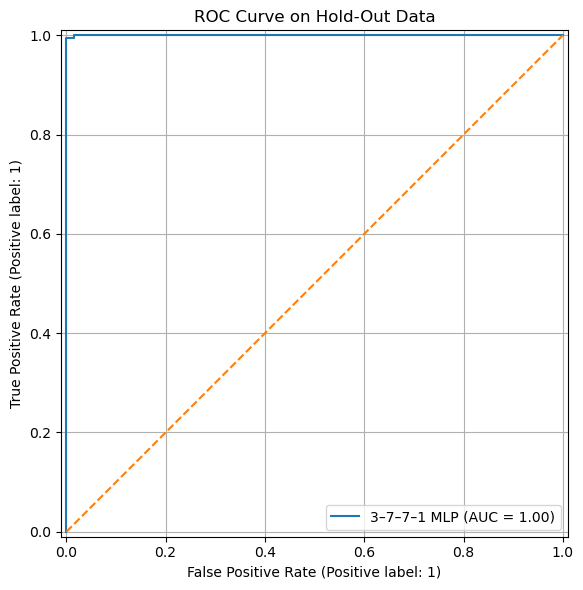

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test,
    p_class1,
    ax=ax,
    name="3–7–7–1 MLP"
)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC Curve on Hold-Out Data")
ax.grid(True)
plt.tight_layout()
plt.show()


## 17. Pull the curtain back open: inspect the learned parameters

At the beginning of the case study, we predicted that the weight matrices should have shapes

\[
(3,7),\qquad(7,7),\qquad(7,1),
\]

and the bias vectors

\[
(7,),\qquad(7,),\qquad(1,).
\]

scikit-learn lets us inspect those learned arrays directly.


In [15]:
print("LEARNED WEIGHT MATRICES")
print("-----------------------")
for i, W in enumerate(model.coefs_, start=1):
    print(f"W{i}: shape = {W.shape}")

print("\nLEARNED BIAS VECTORS")
print("--------------------")
for i, b in enumerate(model.intercepts_, start=1):
    print(f"b{i}: shape = {b.shape}")

total_weights = sum(W.size for W in model.coefs_)
total_biases = sum(b.size for b in model.intercepts_)

print("\nParameter count")
print("Weights:", total_weights)
print("Biases :", total_biases)
print("Total  :", total_weights + total_biases)


LEARNED WEIGHT MATRICES
-----------------------
W1: shape = (3, 7)
W2: shape = (7, 7)
W3: shape = (7, 1)

LEARNED BIAS VECTORS
--------------------
b1: shape = (7,)
b2: shape = (7,)
b3: shape = (1,)

Parameter count
Weights: 77
Biases : 15
Total  : 92


<div style="background:#eef5ff; border-left:5px solid #4c78a8; padding:12px 16px; margin:12px 0;">
<b>Recognize these objects?</b><br><br>
They are exactly the matrices and vectors predicted by the mathematics before scikit-learn ever appeared:
<br><br>
\(W^{(1)}:3\times7\), \(W^{(2)}:7\times7\), \(W^{(3)}:7\times1\)<br>
\(b^{(1)}:7\), \(b^{(2)}:7\), \(b^{(3)}:1\)
<br><br>
A high-level library has not replaced the model. It has packaged its implementation.
</div>


# What scikit-learn hid for us

| Mathematical / computational task | scikit-learn interface |
|---|---|
| Training / hold-out partition | `train_test_split()` |
| Training-set mean and standard deviation | `StandardScaler.fit()` |
| Standardization | `StandardScaler.transform()` |
| Network construction | `MLPClassifier(...)` |
| Hidden-layer dimensions | `hidden_layer_sizes=(7,7)` |
| Sigmoid hidden activation | `activation="logistic"` |
| Mini-batch size | `batch_size=32` |
| Optimizer | `solver="adam"` |
| Parameter initialization | internal to `MLPClassifier` |
| Forward propagation | internal to `fit()` / `predict_proba()` |
| Cross-entropy / log-loss calculation | internal to `fit()` |
| Backpropagation | internal to `fit()` |
| Gradient calculation | internal to `fit()` |
| Parameter updates | internal to Adam solver |
| Repeated epochs | internal to `fit()` |
| Class decision | `predict()` |
| Class probability output | `predict_proba()` |
| Learned weights | `model.coefs_` |
| Learned biases | `model.intercepts_` |

## Final lesson

For the early chapters of this book, hiding these operations would have been pedagogically disastrous. We needed to understand what a learning machine actually does.

Now that the machinery is familiar, abstraction becomes useful.

The line

```python
model.fit(X_train_scaled, y_train)
```

can safely replace pages of implementation because we know what the library is doing underneath.

> **The mathematics has not disappeared. The software has simply taken responsibility for carrying it out.**
